In [14]:
!pip install mne
import mne
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1️⃣ Load EDF File
# -------------------------------------------------
raw = mne.io.read_raw_edf("/content/S001R03.edf", preload=True)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.3 MB/s eta 0:00:00
Extracting EDF parameters from /content/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [23]:
epochs = mne.Epochs(
    raw,
    events,
    event_id=event_id,
    tmin=0,
    tmax=3,
    baseline=None,
    preload=True
)


Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 481 original time points ...
0 bad epochs dropped


In [24]:
print("Channels:", epochs.ch_names)

c3_index = [i for i, ch in enumerate(epochs.ch_names) if "C3.." in ch][0]

Channels: ['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']


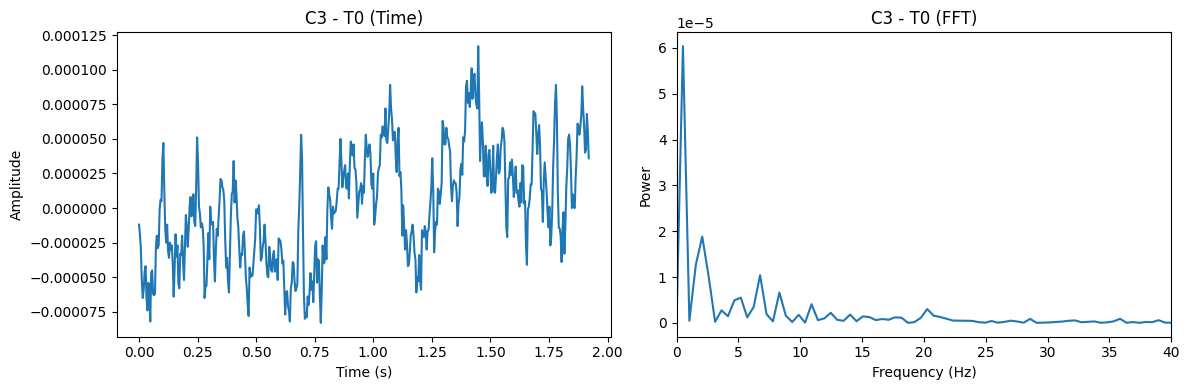

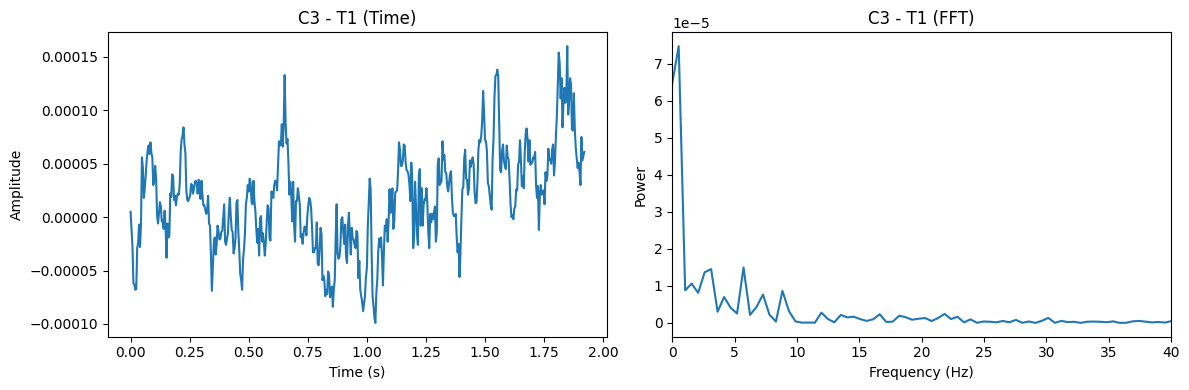

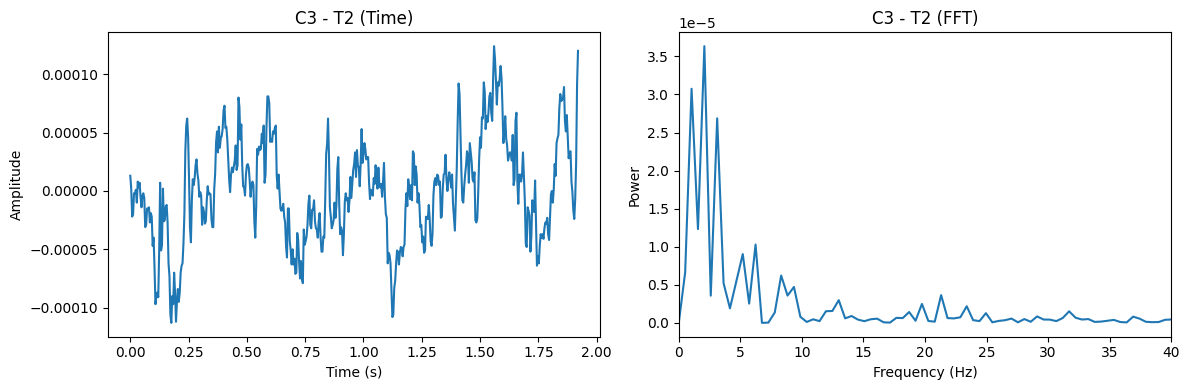

In [30]:
conditions = ['T0', 'T1', 'T2']

for condition in conditions:
    if condition in epochs.event_id:

        data = epochs[condition].get_data()

        if data.shape[0] > 0:

            signal = data[0, c3_index, :]
            time = np.arange(len(signal)) / fs

            # ---- Compute FFT ----
            fft_vals = np.fft.rfft(signal)
            freqs = np.fft.rfftfreq(len(signal), 1/fs)
            power = np.abs(fft_vals)**2

            # ---- Plot ----
            plt.figure(figsize=(12,4))

            # Time Domain
            plt.subplot(1,2,1)
            plt.plot(time, signal)
            plt.title(f"C3 - {condition} (Time)")
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude")

            # Frequency Domain
            plt.subplot(1,2,2)
            plt.plot(freqs, power)
            plt.xlim(0, 40)
            plt.title(f"C3 - {condition} (FFT)")
            plt.xlabel("Frequency (Hz)")
            plt.ylabel("Power")

            plt.tight_layout()
            plt.show()

In [37]:
for condition in conditions:
    if condition in epochs.event_id:

        data = epochs[condition].get_data()
        powers_c3 = []
        powers_c4 = []

        for trial in range(data.shape[0]):

            sig_c3 = data[trial, 8, :]
            sig_c4 = data[trial, 12, :]

            f3 = bandpass_filter(sig_c3, 8, 12, fs)
            f4 = bandpass_filter(sig_c4, 8, 12, fs)

            powers_c3.append(np.log(np.mean(f3**2)))
            powers_c4.append(np.log(np.mean(f4**2)))

        print(f"\n{condition}")
        print("C3:", np.mean(powers_c3))
        print("C4:", np.mean(powers_c4))


T0
C3: -23.026687939943915
C4: -23.21967175171417

T1
C3: -22.753226535591587
C4: -23.16525342834241

T2
C3: -22.81739419906102
C4: -23.06883848771093
